🔴 RISK LAYER 2: FOREIGN DIRECT PRODUCT RULE (FDPR) AUDIT

Purpose: Identify items subject to US jurisdiction under FDPR
Regulatory Basis: 15 CFR § 734.9

📦 Analyzing 5,000 shipments...

📊 RESULTS:
   ┌─ Items under FDPR jurisdiction: 1,293
   ├─ High-risk misclassified items: 679
   └─ Defect Rate: 13.58%

💰 FINANCIAL EXPOSURE:
   Total value of misclassified FDPR items: $431,253,329.98
   Average value per misclassified item: $635,130.09
   Total quantity of items: 171,639

🔍 SAMPLE FDPR DEFECTS:

   ┌─ Shipment: EXP-100000
   ├─ ECCN: 9A004 (should be controlled)
   ├─ Origin: DE
   ├─ Tooling: US (US)
   ├─ Value: $161,042.96
   ├─ Destination: IN
   └─ Business Unit: US-MedicalDevices

   ┌─ Shipment: EXP-100016
   ├─ ECCN: 5A002 (should be controlled)
   ├─ Origin: CN
   ├─ Tooling: US (US)
   ├─ Value: $1,095,332.64
   ├─ Destination: SG
   └─ Business Unit: US-MedicalDevices

   ┌─ Shipment: EXP-100022
   ├─ ECCN: 5A002 (should be controlled)
   ├─ Origin: DE
   ├─ Tooling: US (

Shipment_Count  Total_Exposed_Value
eccn  consignee_country                                     
EAR99 MX                             79          55961435.63
      IE                             85          53636808.43
      SG                             83          50907240.00
      BE                             74          50290582.62
      SA                             77          46599683.49
      CN                             69          45138492.80
      IN                             68          43682096.73
      TW                             66          35607299.16
5A002 BE                             33          25628100.43
      CN                             29          21577590.74


📊 FDPR Violations by ECCN Code:


eccn
5A002    233
3A001    190
9A004    133
5A001    123
Name: count, dtype: int64


📊 FDPR VIOLATIONS BY BUSINESS UNIT:


,Business Unit,FDPR Violations,Total_Value
1,US-ConsumerElectronics,212,1.395802e+08
3,US-MedicalDevices,174,1.135832e+08
2,US-IndustrialEquipment,135,7.479718e+07
0,US-AerospaceParts,107,7.103582e+07
4,US-Pharmaceuticals,51,3.225697e+07


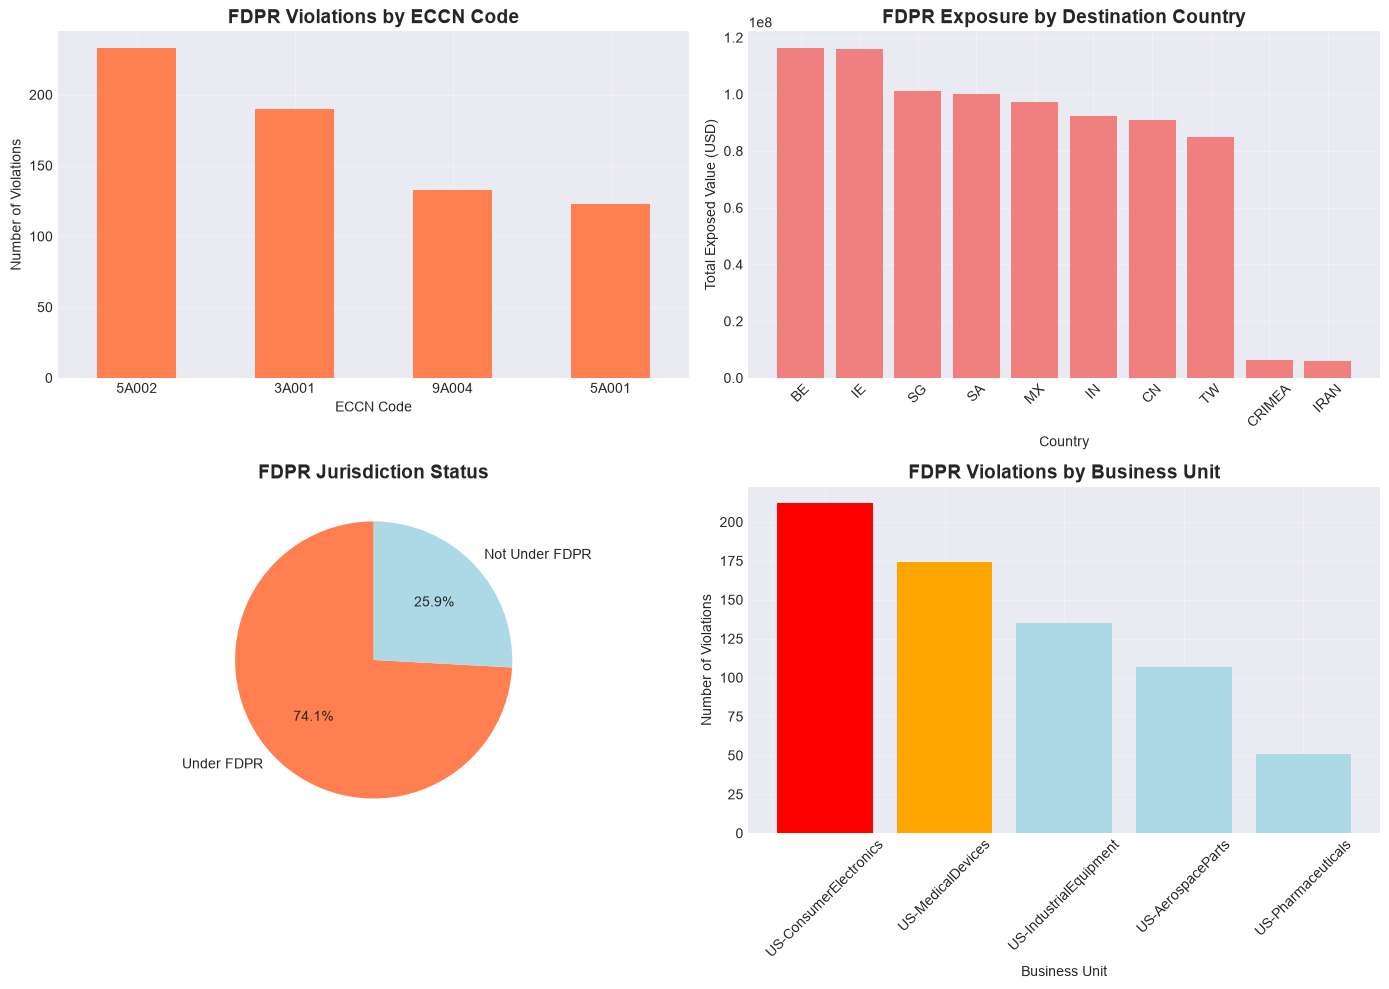


💾 Saved: output/risk_layer2_fdpr_auditing.png

💾 Saved: us_export_compliance_data_layer2.csv

✅ RISK LAYER 2 COMPLETE!


In [1]:
# %% [markdown]
# # 🔴 Risk Layer 2: Foreign Direct Product Rule (FDPR) Auditing
# 
# **Purpose**: Identify items subject to US jurisdiction under FDPR
# 
# **Regulatory Basis**: 15 CFR § 734.9
# 
# **Key Question**: Are we misclassifying items that are actually under US jurisdiction?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🔴 RISK LAYER 2: FOREIGN DIRECT PRODUCT RULE (FDPR) AUDIT")
print("="*70)
print("\nPurpose: Identify items subject to US jurisdiction under FDPR")
print("Regulatory Basis: 15 CFR § 734.9")

# %% [code]
# Load dataset with Layer 1 enhancements
df = pd.read_csv('us_export_compliance_data_layer1.csv', parse_dates=['shipment_date', 'clearance_date'])

print(f"\n📦 Analyzing {len(df):,} shipments...")

# %% [markdown]
# ## FDPR Jurisdiction Logic
# 
# **Rule**: Items produced abroad using US-origin tooling/software
# - `bom_origin_country != 'US'` (Not manufactured in US)
# - `bom_tooling_origin == 'US'` (Uses US tooling/software)

# %% [code]
# Apply FDPR jurisdiction logic
df['fdpr_jurisdiction_flag'] = (
    (df['bom_origin_country'] != 'US') & 
    (df['bom_tooling_origin'] == 'US')
)

# High-risk FDPR: Items under US jurisdiction but misclassified
df['fdpr_high_risk'] = (
    df['fdpr_jurisdiction_flag'] & 
    (~df['eccn'].isin(['EAR99', 'NLR']))  # Not properly classified as EAR99
)

# Count results
fdpr_jurisdiction_count = df['fdpr_jurisdiction_flag'].sum()
fdpr_high_risk_count = df['fdpr_high_risk'].sum()

print(f"\n📊 RESULTS:")
print(f"   ┌─ Items under FDPR jurisdiction: {fdpr_jurisdiction_count:,}")
print(f"   ├─ High-risk misclassified items: {fdpr_high_risk_count:,}")
print(f"   └─ Defect Rate: {fdpr_high_risk_count/len(df)*100:.2f}%")

# %% [markdown]
# ## Financial Exposure Analysis

# %% [code]
if fdpr_high_risk_count > 0:
    # Financial exposure
    fdpr_exposure = df[df['fdpr_high_risk']]['total_value_usd'].sum()
    fdpr_avg_value = df[df['fdpr_high_risk']]['total_value_usd'].mean()
    fdpr_total_quantity = df[df['fdpr_high_risk']]['item_quantity'].sum()
    
    print(f"\n💰 FINANCIAL EXPOSURE:")
    print(f"   Total value of misclassified FDPR items: ${fdpr_exposure:,.2f}")
    print(f"   Average value per misclassified item: ${fdpr_avg_value:,.2f}")
    print(f"   Total quantity of items: {fdpr_total_quantity:,}")
    
    # Show examples
    print("\n🔍 SAMPLE FDPR DEFECTS:")
    sample_fdpr = df[df['fdpr_high_risk']][
        ['shipment_id', 'eccn', 'bom_origin_country', 'bom_tooling_origin', 
         'total_value_usd', 'consignee_country', 'exporter_business_unit']
    ].head(5)
    
    for idx, row in sample_fdpr.iterrows():
        print(f"\n   ┌─ Shipment: {row['shipment_id']}")
        print(f"   ├─ ECCN: {row['eccn']} (should be controlled)")
        print(f"   ├─ Origin: {row['bom_origin_country']}")
        print(f"   ├─ Tooling: {row['bom_tooling_origin']} (US)")
        print(f"   ├─ Value: ${row['total_value_usd']:,.2f}")
        print(f"   ├─ Destination: {row['consignee_country']}")
        print(f"   └─ Business Unit: {row['exporter_business_unit']}")

# %% [markdown]
# ## FDPR Risk Matrix
# 
# Cross-tabulation of ECCN codes and destination countries

# %% [code]
if fdpr_jurisdiction_count > 0:
    print("\n📊 FDPR RISK MATRIX:")

    # Create the matrix
    fdpr_matrix = df[df['fdpr_jurisdiction_flag']].groupby(
        ['eccn', 'consignee_country']
    ).agg({
        'shipment_id': 'count',
        'total_value_usd': 'sum'
    }).round(2)

    fdpr_matrix.columns = ['Shipment_Count', 'Total_Exposed_Value']
    fdpr_matrix = fdpr_matrix.sort_values('Total_Exposed_Value', ascending=False)

    print("\nTop FDPR Risks (ECCN × Country):")
    display(fdpr_matrix.head(10))

# %% [markdown]
# ## Analysis by ECCN Code
# 
# Which ECCN codes have the most FDPR violations?

# %% [code]
eccn_fdpr = df[df['fdpr_high_risk']]['eccn'].value_counts()
print("\n📊 FDPR Violations by ECCN Code:")
display(eccn_fdpr)

# %% [markdown]
# ## Analysis by Business Unit

# %% [code]
bu_fdpr = df[df['fdpr_high_risk']].groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'total_value_usd': 'sum'
}).reset_index()

bu_fdpr.columns = ['Business Unit', 'FDPR Violations', 'Total_Value']
bu_fdpr = bu_fdpr.sort_values('FDPR Violations', ascending=False)

print("\n📊 FDPR VIOLATIONS BY BUSINESS UNIT:")
display(bu_fdpr)

# %% [markdown]
# ## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('output'):
    os.makedirs('output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. FDPR violations by ECCN
if len(eccn_fdpr) > 0:
    eccn_fdpr.plot(kind='bar', ax=axes[0,0], color='coral')
    axes[0,0].set_title('FDPR Violations by ECCN Code', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('ECCN Code')
    axes[0,0].set_ylabel('Number of Violations')
    axes[0,0].tick_params(axis='x', rotation=0)
    axes[0,0].grid(True, alpha=0.3)

# 2. FDPR exposure by country
fdpr_by_country = df[df['fdpr_jurisdiction_flag']].groupby('consignee_country').agg({
    'total_value_usd': 'sum',
    'shipment_id': 'count'
}).reset_index()

if len(fdpr_by_country) > 0:
    fdpr_by_country_sorted = fdpr_by_country.sort_values('total_value_usd', ascending=False).head(10)
    axes[0,1].bar(fdpr_by_country_sorted['consignee_country'], 
                  fdpr_by_country_sorted['total_value_usd'], 
                  color='lightcoral')
    axes[0,1].set_title('FDPR Exposure by Destination Country', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Country')
    axes[0,1].set_ylabel('Total Exposed Value (USD)')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].grid(True, alpha=0.3)

# 3. FDPR jurisdiction flag distribution
fdpr_status = df['fdpr_jurisdiction_flag'].value_counts()
labels = ['Under FDPR', 'Not Under FDPR']
colors_status = ['coral', 'lightblue']
axes[1,0].pie(fdpr_status.values, labels=labels, autopct='%1.1f%%', colors=colors_status, startangle=90)
axes[1,0].set_title('FDPR Jurisdiction Status', fontsize=14, fontweight='bold')

# 4. FDPR violations by business unit
if len(bu_fdpr) > 0:
    bu_fdpr_sorted = bu_fdpr.sort_values('FDPR Violations', ascending=False)
    colors_bu = ['red' if i == 0 else 'orange' if i == 1 else 'lightblue' for i in range(len(bu_fdpr_sorted))]
    axes[1,1].bar(bu_fdpr_sorted['Business Unit'], bu_fdpr_sorted['FDPR Violations'], color=colors_bu)
    axes[1,1].set_title('FDPR Violations by Business Unit', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Business Unit')
    axes[1,1].set_ylabel('Number of Violations')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/risk_layer2_fdpr_auditing.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/risk_layer2_fdpr_auditing.png")

# %% [code]
# Save the enhanced dataset
df.to_csv('us_export_compliance_data_layer2.csv', index=False)
print("\n💾 Saved: us_export_compliance_data_layer2.csv")

print("\n" + "="*70)
print("✅ RISK LAYER 2 COMPLETE!")
print("="*70)